In [1]:
# Source https://github.com/leonardompp/Qiskit-Fall-Fest-2024-Submission
# Built-in modules
import math

# Imports from Qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT, Initialize, UnitaryGate
from qiskit.visualization import plot_bloch_multivector,plot_distribution, plot_histogram
from qiskit_aer.primitives import SamplerV2
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import time
from IPython.display import display
import numpy as np
import math
from fractions import Fraction 

# Imports from Qiskit Runtime
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Initialize the Qiskit Runtime Service
from test_utils import read_account_file

In [2]:
account = read_account_file('account_info.conf')
service = QiskitRuntimeService(channel="ibm_cloud", instance=account['instance'], token=account['token'])
backend = service.least_busy()
print(f"Using backend: {backend.name}")

Using backend: ibm_torino


In [3]:
#########################################################################
##################### CHANGE HERE FOR DIFFERENT n #######################
#########################################################################
# Number of qbits in the system
n = 5
#########################################################################

# Create the quantum circuit with the number of specified qubits
q_register = []
for i in range(n):
    q_register.append(QuantumRegister(1, f'q{i}'))


# Sweep through all basis states
for j in range(pow(2, n)):
  # Reset the circuit
  qc = QuantumCircuit(*q_register)
  # For each application of QFT, we need to change the "input" state
  # This can be done by finding the binary representation of each number
  j_binary = bin(j)
  # Sweep in reverse to keep bit order
  temp = -1
  while j_binary[temp] != "b":
    # Values start on state 0, we bit flip what is one
    if j_binary[temp] == '1':
      qc.x(abs(temp)-1)
    temp -= 1

  # Input
  init_state = Statevector(qc)
  #display(plot_bloch_multivector(init_state, title=f"State |{j}> on {n} qubits", reverse_bits=True))

  # Add a QFT to the circuit
  qfc = QFT(num_qubits=n, name='QFT')
  qc.append(qfc, list(range(n)))

  # Output
  final_state = Statevector(qc)
  #display(plot_bloch_multivector(final_state, title=f"State QFT|{j}> on {n} qubits", reverse_bits=True))

  # Circuit for sanity/separation
  #display(qc.draw('mpl', initial_state=True, reverse_bits=True))  # Reverse for visualization, highest is MSQ

Number of eigenstate qubits needed   : 1
Job ID: d20aa63ni11c73fcfhj0


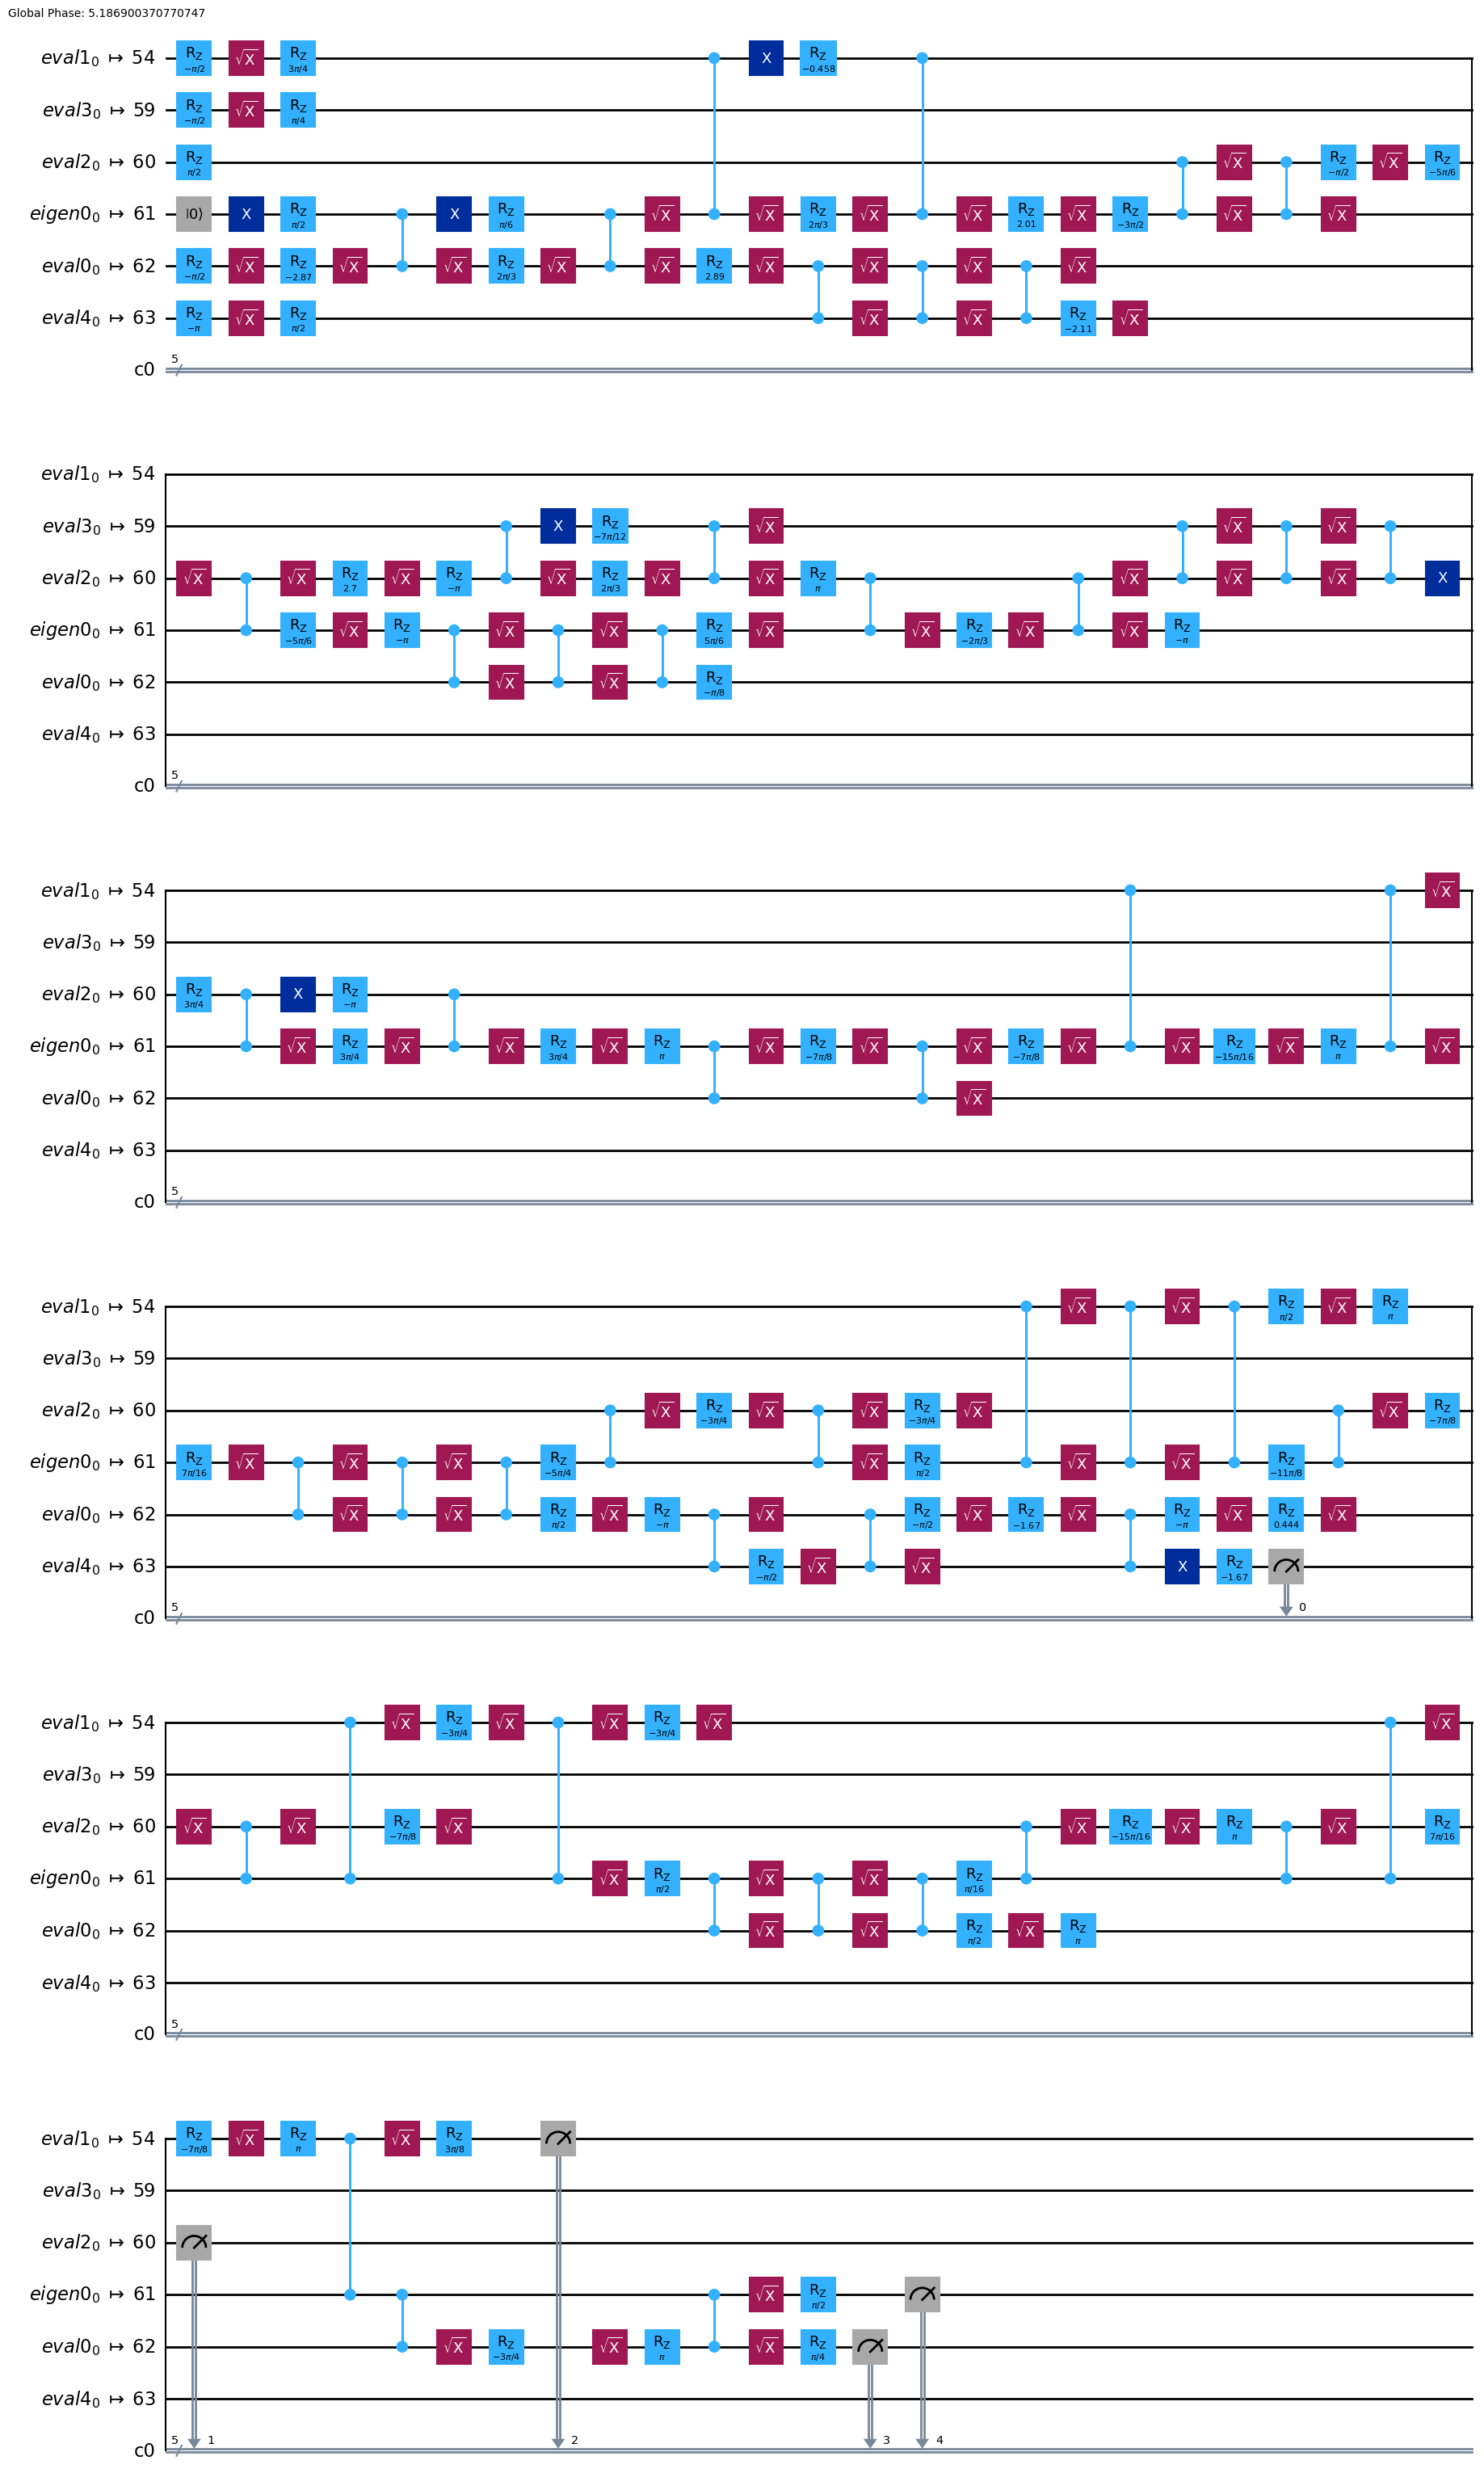

In [4]:
#########################################################################
############# CHANGE HERE FOR DIFFERENT U, |phi> and n ##################
#########################################################################
# Evaluation qubits register
n_eval = 5

# Suggested examples
# Y gate with eigstate |+i>:
# U = np.array([[0, 1], [-1, 0]]) phi = (1/np.sqrt(2))*np.array([1, 1j]) -> theta = 1/4 (exact measurement)

# Phase shift gate with eigstate |1>:
# U = np.array([[1, 0], [0, np.exp(1j*2*np.pi/3)]]) phi = np.array([0, 1]) -> theta = 1/3 (probabilistic measurement)

# CNOT gate with eigstate |00>
# U = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]]) phi = np.array([1, 0, 0, 0]) -> theta = 0 (exact measurement)

U = np.array([[1, 0], [0, np.exp(1j*2*np.pi/3)]])
phi = np.array([0, 1])
#########################################################################


# Qubits in eigenstate register
n_eigen = int(np.log2(phi.size))
print(f"Number of eigenstate qubits needed   : {n_eigen}")

# Build circuit structure
eigen_register = []
for i in range(n_eigen):
    eigen_register.append(QuantumRegister(1, f"eigen{i}"))
eval_register = []
for i in range(n_eval):
    eval_register.append(QuantumRegister(1, f"eval{i}"))
qc = QuantumCircuit(*eigen_register, *eval_register, ClassicalRegister(n_eval))

# Initialize eigenstate
init_gate = Initialize(Statevector(phi))
qc.append(init_gate, list(range(n_eigen)))

# Initialize hadamards on eval qubits
for i in range(n_eval):
  qc.h(i + n_eigen)

# Add CU^(2^x) gates
for i in range(n_eval):
    power = pow(2, i)
    compound_u = np.linalg.matrix_power(U, power)
    compound_u_gate = UnitaryGate(compound_u)
    compound_u_gate.name = f"$CU^{2**i}$"
    controlled_u_gate = compound_u_gate.control()
    qc.append(controlled_u_gate, [i+n_eigen, *list(range(n_eigen))])

# Inverse qft
qft = QFT(num_qubits=n_eval)
qft_inverse = qft.inverse()
qc.append(qft_inverse, [i+n_eigen for i in range(n_eval)])

# Assign measurements
for i in range(n_eval):
    qc.measure(i+n_eigen, i)

# Draw circuit
#display(qc.draw('mpl', initial_state=True, reverse_bits=True))  # Reverse for visualization, highest is MSQ

# Simulate the circuit
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

transpiled_circuit = pm.run(qc)
transpiled_circuit.draw(output="mpl", idle_wires=False, style="iqp")  
# Create a sampler instance
sampler = Sampler(mode=backend)
# Sample the transpiled circuit
job = sampler.run([transpiled_circuit], shots=1024)
print(f"Job ID: {job.job_id()}")

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
C:\Users\karim\AppData\Local\Temp\ipykernel_3652\585703373.py:8: SyntaxWarning: invalid escape sequence '\p'
  display(plot_histogram(data, title=f"QPE $(U, |\phi>)$ on {n_eval} eval qubits"))


[ClassicalRegister(5, 'c0')]


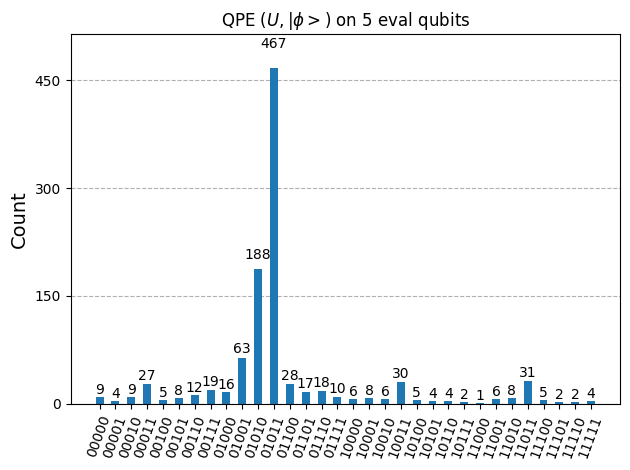

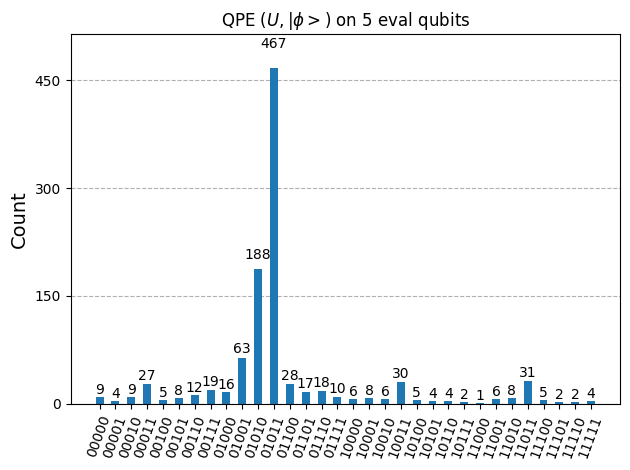

In [5]:
#data = result.get_counts(qct)
result = job.result()
#print(f"{result[0].data}")
# Get the counts (measurement results)
print(f"{transpiled_circuit.cregs}")
data = result[0].data.c0.get_counts()

display(plot_histogram(data, title=f"QPE $(U, |\phi>)$ on {n_eval} eval qubits"))

In [6]:
#########################################################################
################## CHANGE HERE FOR DIFFERENT a, N #######################
#########################################################################
N = 21
a = 5
#########################################################################

# Calculate size of the eigenstate register
eigen_qubits = math.ceil(np.log2(N))
# Calculate size of the evaluation register
eval_qubits = math.ceil(np.log2(pow(N, 2)))
print(f"Eigenstate qubits: {eigen_qubits}")
print(f"Evaluation qubits: {eval_qubits}")

 # Build circuit structure
eigen_register = []
for i in range(eigen_qubits):
    eigen_register.append(QuantumRegister(1, f"eigen{i}"))
eval_register = []
for i in range(eval_qubits):
    eval_register.append(QuantumRegister(1, f"eval{i}"))
qc = QuantumCircuit(*eigen_register, *eval_register, ClassicalRegister(eval_qubits))

# Circuit creation
# Start state |1> on eigenstate register to superpose |us>
qc.x(0)

# Start hadamards on evaluation register
# These will be part of the QPE circuit
for i in range(eval_qubits):
    qc.h(i + eigen_qubits)


# This creates operator U based on modular arithmetic
def generate_base_matrix(a, N, eigen_qubits):
    # Build the matrix, which must support 2**eigen_qubits elements
    u = np.zeros([2 ** eigen_qubits, 2 ** eigen_qubits], dtype=int)
    # Elements in 0 <= i <= N-1
    for i in range(N):
        u[a * i % N][i] = 1
    # For the rest, it is irrelevant. We'll not deal with these states
    for i in range(N, 2 ** eigen_qubits):
        u[i][i] = 1
    return u

# Build controlled U operators
u = generate_base_matrix(a, N, eigen_qubits)
for i in range(eval_qubits):
    power = pow(2, i)
    compound_u = np.linalg.matrix_power(u, power)
    compound_u_gate = UnitaryGate(compound_u)
    compound_u_gate.name = f"CU^{2 ** i}"
    controlled_u_gate = compound_u_gate.control()
    qc.append(controlled_u_gate, [i + eigen_qubits, *list(range(eigen_qubits))])

# Inverse qft
qft = QFT(num_qubits=eval_qubits)
qft_inverse = qft.inverse()
qc.append(qft_inverse, [i + eigen_qubits for i in range(eval_qubits)])

# Assign measurements
for i in range(eval_qubits):
    qc.measure(i + eigen_qubits, i)

# Draw
#display(qc.draw('mpl', initial_state=True, reverse_bits=True))

target = backend.target
pm2 = generate_preset_pass_manager(target=target, optimization_level=3)

circuit_isa = pm.run(qc)
#circuit_isa.draw(output="mpl", idle_wires=False, style="iqp")  
# Create a sampler instance
sampler2 = Sampler(mode=backend)
# Sample the transpiled circuit
job2 = sampler2.run([circuit_isa], shots=1024)
print(f"Job ID: {job2.job_id()}")


#data = result.get_counts(qct)


Eigenstate qubits: 5
Evaluation qubits: 9
Job ID: d20ac53ni11c73fcfjbg


[ClassicalRegister(9, 'c1')]
Measurement results: {'111010000': 4, '100101011': 2, '010110111': 2, '000110100': 8, '100111100': 3, '100011010': 4, '010001100': 5, '000111100': 3, '110110010': 5, '111101010': 1, '011100100': 4, '101010101': 2, '100010010': 3, '001111001': 2, '010011110': 2, '100100000': 3, '110011010': 1, '100010100': 6, '100111010': 3, '010011000': 5, '011000110': 5, '011111010': 5, '100101001': 2, '101001111': 2, '100111110': 8, '000001110': 2, '100001101': 2, '011010011': 1, '100000010': 2, '000110000': 5, '100000110': 2, '010100110': 4, '111111000': 2, '000101010': 4, '100011000': 2, '001010000': 4, '111110001': 1, '110100010': 3, '100110001': 3, '100100010': 3, '100001100': 2, '011001000': 3, '110011000': 4, '110010111': 1, '001010110': 5, '001110100': 4, '100001000': 5, '110111100': 5, '010110000': 6, '110100001': 2, '011001101': 3, '010101100': 5, '111010100': 2, '100111000': 1, '000110001': 2, '001010101': 3, '000000010': 4, '010011010': 2, '010010100': 4, '1010

C:\Users\karim\AppData\Local\Temp\ipykernel_3652\2382170177.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(data2).show()


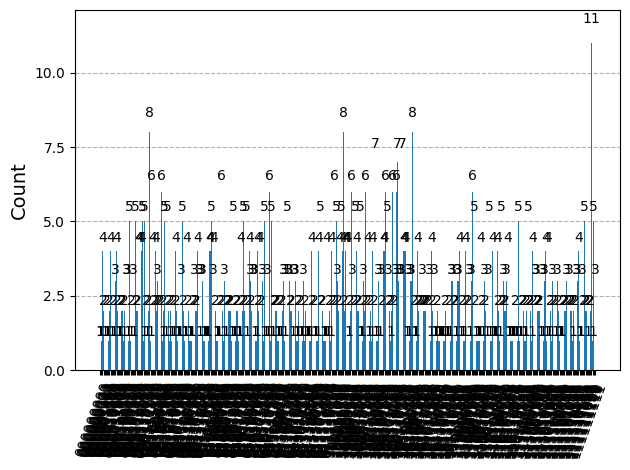

In [7]:
#job = service.job('d1h5ee5qbivc73edqcp0')

result2 = job2.result()
print(f"{circuit_isa.cregs}")
# Get the counts (measurement results)
data2 = result2[0].data.c1.get_counts()

# Print the results
print("Measurement results:", data2) 
# Optionally, visualize the results
plot_histogram(data2).show()

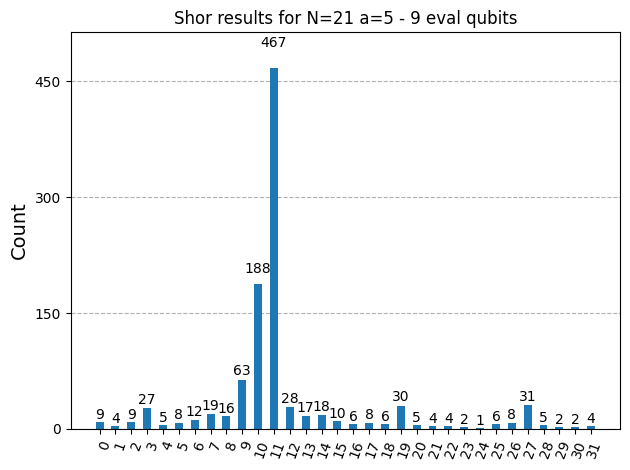

Order of element a=5 base N=21 is r=18


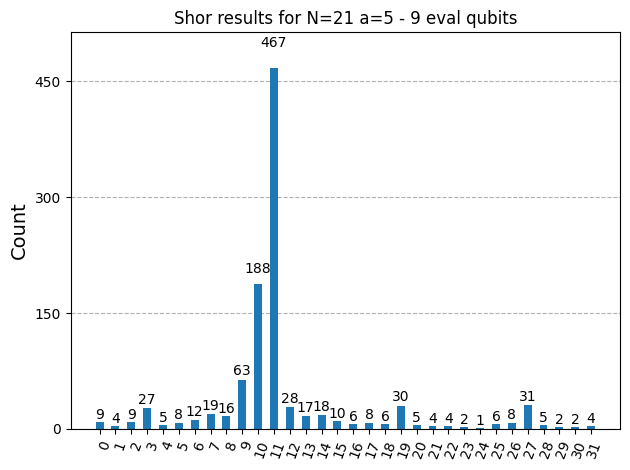

In [8]:
# Make data decimal for easier viewing
data_dec = dict()
for bin_key in data.keys():
    data_dec[int(bin_key, 2)] = data[bin_key]
display(plot_histogram(data_dec, title=f"Shor results for N={N} a={a} - {eval_qubits} eval qubits"))

# Order the values by largest measurement
sorted_measurements = [key for key, _ in sorted(data_dec.items(), key=lambda item: item[1], reverse=True)]

# Try multiple measurements to see if any work
found = False
i = 0
r = 0
while not found and i < len(sorted_measurements):
  v = sorted_measurements[i]
  frac = Fraction(v, 2**eval_qubits)
  test_order = frac.limit_denominator(max_denominator=N).denominator
  if pow(a, test_order, N) == 1:
    found = True
    r = test_order
  else:
    i += 1

if found:
  print(f"Order of element a={a} base N={N} is r={r}")
else:
  print(f"Order not found :-(. Try running again")

In [9]:
## REMEMBER TO RUN THE PREVIOUS CELL BEFORE RUNNING THIS ONE ##
print(f"From the previous cell, we found that element a={a} has order r={r} mod N={N}")

# Classical part of Shor
p = 0
q = 0
if math.gcd(a, N) == 1:
  if r%2 == 0:
    lv = pow(a, r//2) + 1
    rv = pow(a, r//2) - 1
    p_test = math.gcd(lv, N)
    q_test = math.gcd(rv, N)
    if p_test*q_test == N:
      p = p_test
      q = q_test
    else:
      print(f"p*q is not N. Try a different value of a")
  else:
    print(f"Order r={r} is not even! Try a different value of a")
else:
  print(f"Lucky, a={a} is already a factor of N={N}")
  p = a
  q = N//a

if p*q != 0:
  print(f"Factors of N={N} are p={p} and q={q}")

From the previous cell, we found that element a=5 has order r=18 mod N=21
Factors of N=21 are p=21 and q=1
